### Comparison Analysis: MNIST and MovieLens

This notebook compares optimization behavior across two different machine learning problems: MNIST digit classification and MovieLens recommendation modeling.

MNIST represents a dense image classification task, while MovieLens represents a sparse user-item recommendation task. The main goal is to compare how optimization methods and model structures behave across these different data settings.

### 1. Project Setup and Paths

In [22]:
from pathlib import Path
print(Path.cwd())

c:\Users\edwin\Desktop\PSU_Academics\MTH_563_Computational_Method_DS\computatinal_ml_project\notebooks


In [23]:
# Project Setup and Paths

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Base project directory
project_root = Path("..")

# Figure directories
figures_dir = project_root / "figures"

mnist_fig_dir = figures_dir / "mnist"
movielens_fig_dir = figures_dir / "movielens"
comparison_fig_dir = figures_dir / "comparison"

# Results directories
results_dir = project_root / "results"

mnist_results_dir = results_dir / "mnist"
movielens_results_dir = results_dir / "movielens"
comparison_results_dir = results_dir / "comparison"

# Create comparison folders if needed
for folder in [
    comparison_fig_dir,
    comparison_results_dir
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root.resolve())
print("Comparison figures:", comparison_fig_dir.resolve())
print("Comparison results:", comparison_results_dir.resolve())

Project root: C:\Users\edwin\Desktop\PSU_Academics\MTH_563_Computational_Method_DS\computatinal_ml_project
Comparison figures: C:\Users\edwin\Desktop\PSU_Academics\MTH_563_Computational_Method_DS\computatinal_ml_project\figures\comparison
Comparison results: C:\Users\edwin\Desktop\PSU_Academics\MTH_563_Computational_Method_DS\computatinal_ml_project\results\comparison


### 2. Load Final MNIST Results

In [24]:
#  MNIST Results

mnist_summary_df = pd.read_csv(mnist_results_dir / "mnist_summary.csv")

print("MNIST summary loaded successfully")
display(mnist_summary_df)

MNIST summary loaded successfully


,Model,Final Train Loss,Final Test Loss,Final Test Accuracy,Runtime (seconds)
0,Single SGD,0.0222,0.0335,0.9890,324.8484
1,Single Adam,0.0069,0.0358,0.9901,308.8866
2,Multilevel SGD,0.0245,0.0321,0.9894,370.9826
3,Multilevel Adam,0.0108,0.0353,0.9893,369.6899


#### 3. Load Final MovieLens Results

In [25]:
# MovieLens Results

movielens_summary_df = pd.read_csv(movielens_results_dir / "movielens_summary.csv")

print("MovieLens summary loaded successfully")
display(movielens_summary_df)

MovieLens summary loaded successfully


,Model,Final Train RMSE,Final Test RMSE,Runtime (seconds)
0,Global Mean Baseline,NaN,1.0355,NaN
1,SGD,0.5793,0.8501,120.9348
2,Adam,0.4792,0.8508,409.1822
3,Multilevel SGD,0.7161,0.8593,96.6596
4,Multilevel Adam,0.6366,0.8585,449.6955


#### 4. MNIST Model Comparison

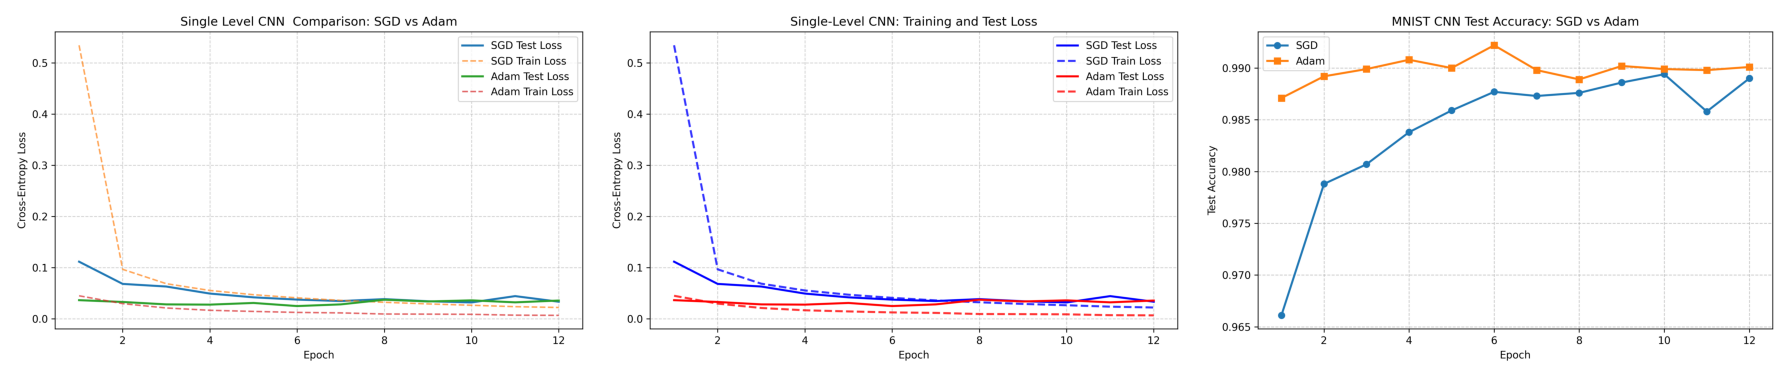

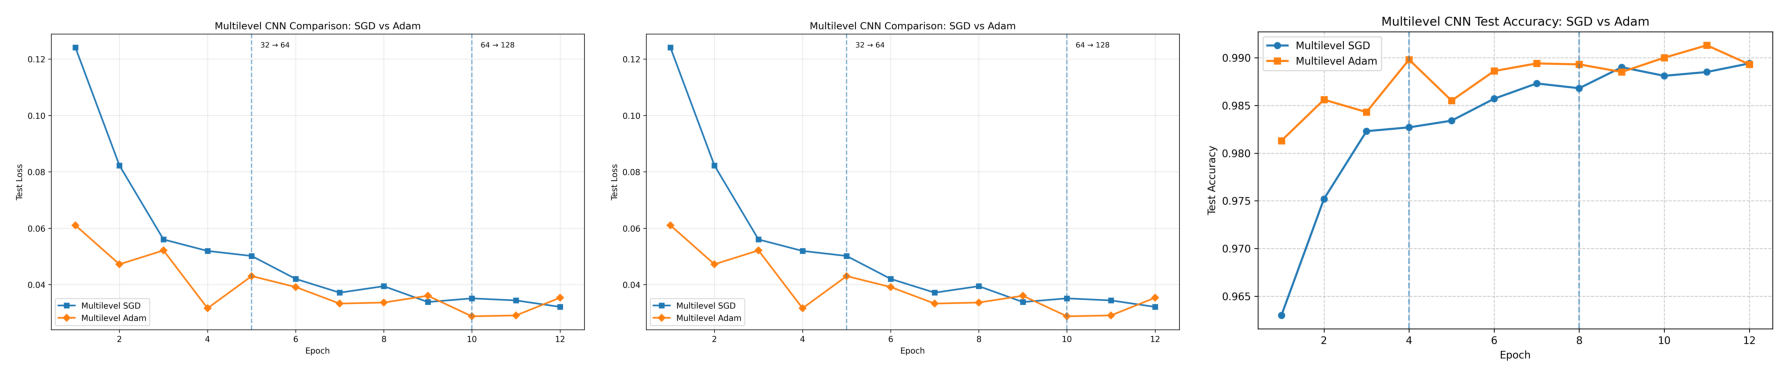

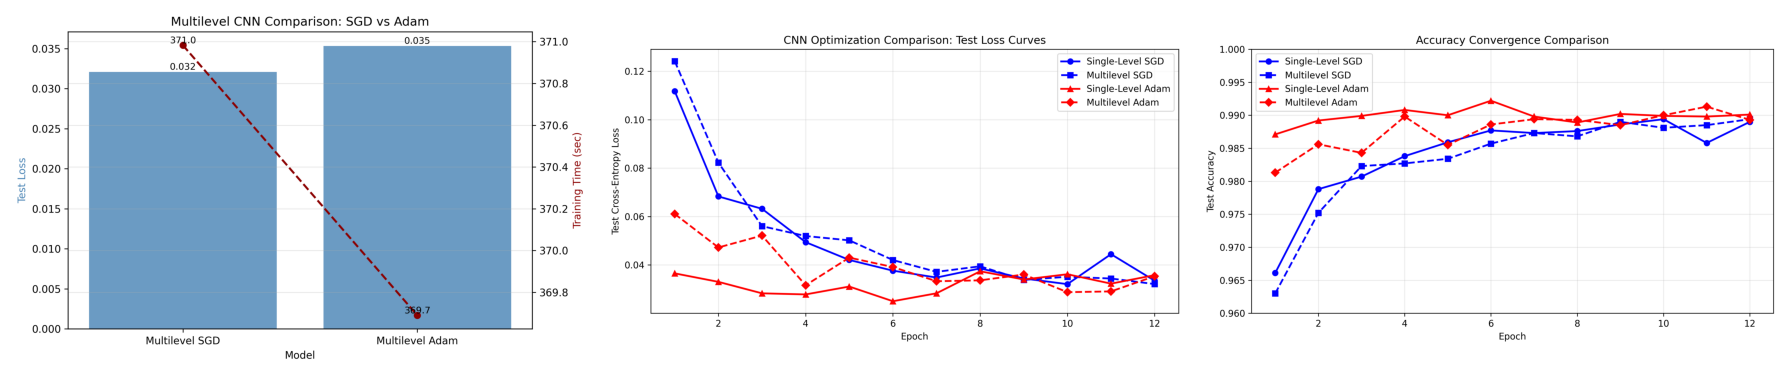

In [26]:
# MNIST Model Comparison 

mnist_plot_groups = [

    # Single-Level CNN Results
    [
        "single_level SGD vs Adam.png",
        "single_level_cnn_sgd_vs_adam_loss.png",
        "single_level_cnn_sgd_vs_adam_accuracy.png"
    ],

    # Multilevel CNN Results
    [
        "multilevel_sgd_vs_adam_loss.png",
        "multilevel_cnn_sgd_vs_adam_loss.png",
        "multilevel_cnn_sgd_vs_adam_accuracy.png"
    ],

    # Runtime + Final Comparison
    [
        "multilevel_cnn_sgd_vs_adam_runtime.png",
        "comparison_level_cnn_sgd_vs_adam_loss.png",
        "comparison_level_cnn_sgd_vs_adam_accuracy.png"
    ]
]

# Display grouped plots

for group in mnist_plot_groups:

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, plot_name in zip(axes, group):

        img_path = mnist_fig_dir / plot_name

        if img_path.exists():

            img = plt.imread(img_path)

            ax.imshow(img)
            ax.axis("off")

        else:
            ax.text(
                0.5,
                0.5,
                f"Missing:\n{plot_name}",
                ha="center",
                va="center"
            )
            ax.axis("off")

    plt.tight_layout()
    plt.show()

#### 5. MovieLens Model Comparison

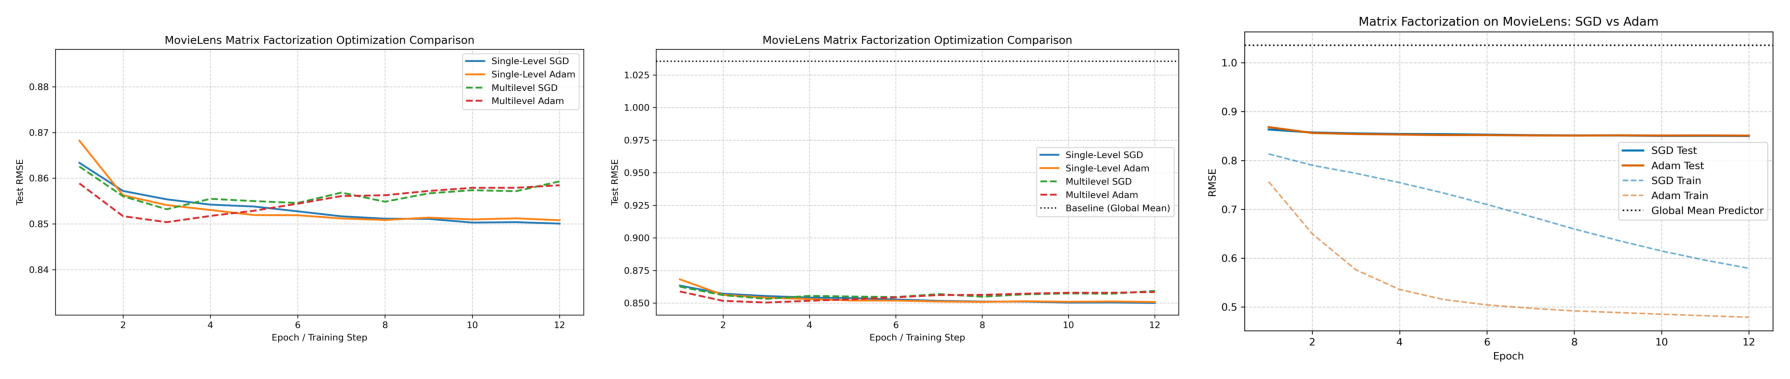

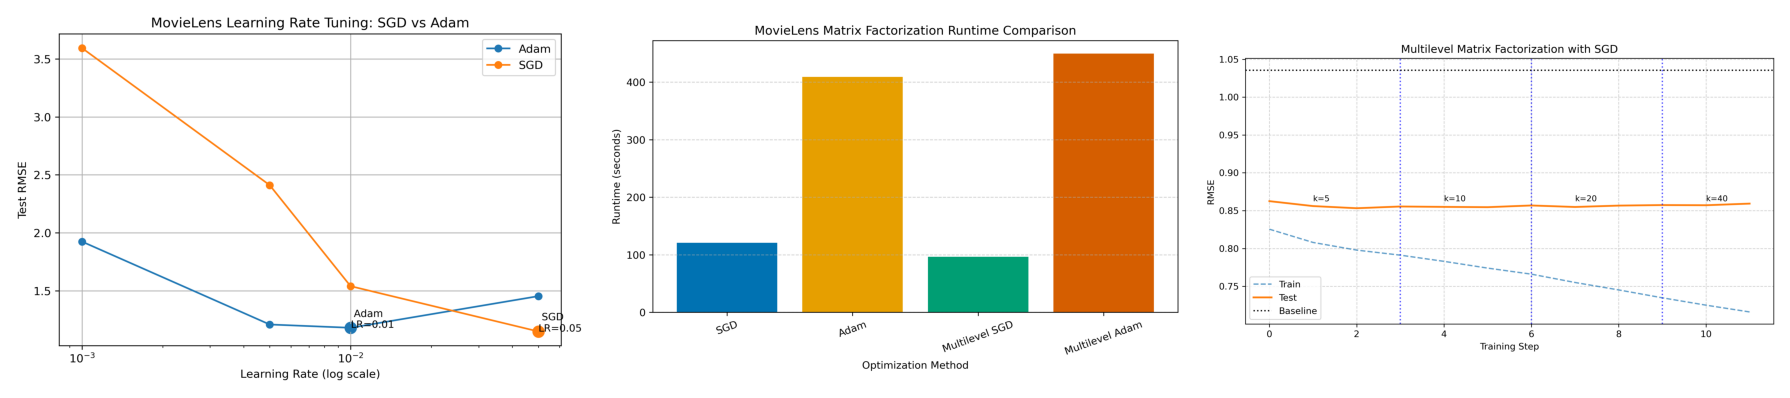

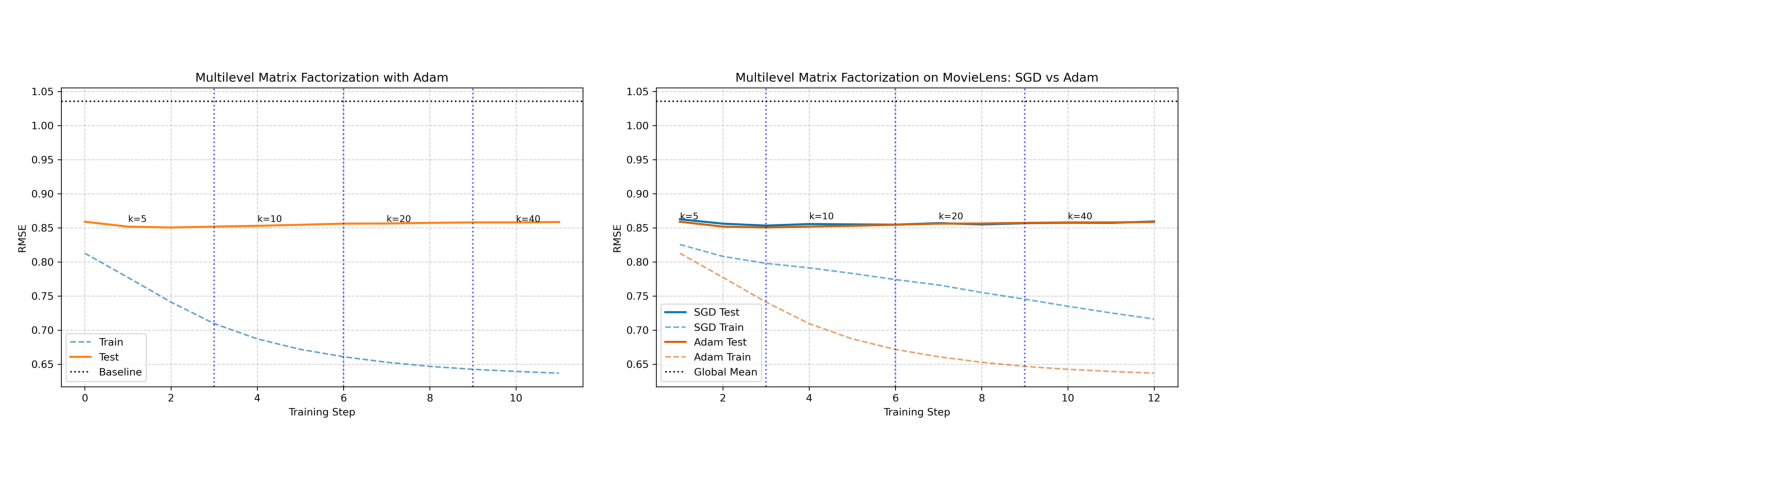

In [27]:
# MovieLens Model Comparison

movielens_plot_groups = [

    
    # Baseline + SGD vs Adam Comparison
    
    [
        "comparison_mf_rmse_plot_sgd_vs_adam_wGMP.png",
        "comparison_mf_rmse_plot_sgd_vs_adam.png",
        "mf_rmse_plot_sgd_vs_adam.png"
    ],

    # Learning Rate + Runtime + Multilevel SGD
    [
        "lr_tuning_plot.png",
        "mf_runtime_plot_sgd_vs_adam.png",
        "multilevel_mf_rmse_plot_sgd.png"
    ],

    # Multilevel Adam + Combined Multilevel
    [
        "multilevel_mf_rmse_plot_adam.png",
        "multilevel_mf_rmse_plot_sgd_vs_adam.png"
    ]
]

#  Display grouped plots

for group in movielens_plot_groups:

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Handle groups with fewer than 3 plots
    if len(group) < 3:
        axes = np.array(axes).flatten()

    for ax, plot_name in zip(axes, group):

        img_path = movielens_fig_dir / plot_name

        if img_path.exists():

            img = plt.imread(img_path)

            ax.imshow(img)
            ax.axis("off")

        else:
            ax.text(
                0.5,
                0.5,
                f"Missing:\n{plot_name}",
                ha="center",
                va="center"
            )
            ax.axis("off")

    # Hide unused subplot if group has fewer than 3 plots
    if len(group) < 3:
        for ax in axes[len(group):]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

#### 6. Cross-Dataset Comparison

In [28]:
# Cross-Dataset Comparison

print("MNIST Final Results")
display(mnist_summary_df)

print("MovieLens Final Results")
display(movielens_summary_df)

# Save combined comparison tables

mnist_summary_df.to_csv(
    comparison_results_dir / "final_mnist_comparison.csv",
    index=False
)

movielens_summary_df.to_csv(
    comparison_results_dir / "final_movielens_comparison.csv",
    index=False
)

print("Final comparison CSV files saved successfully")

MNIST Final Results


,Model,Final Train Loss,Final Test Loss,Final Test Accuracy,Runtime (seconds)
0,Single SGD,0.0222,0.0335,0.9890,324.8484
1,Single Adam,0.0069,0.0358,0.9901,308.8866
2,Multilevel SGD,0.0245,0.0321,0.9894,370.9826
3,Multilevel Adam,0.0108,0.0353,0.9893,369.6899


MovieLens Final Results


,Model,Final Train RMSE,Final Test RMSE,Runtime (seconds)
0,Global Mean Baseline,NaN,1.0355,NaN
1,SGD,0.5793,0.8501,120.9348
2,Adam,0.4792,0.8508,409.1822
3,Multilevel SGD,0.7161,0.8593,96.6596
4,Multilevel Adam,0.6366,0.8585,449.6955


Final comparison CSV files saved successfully


#### 7. Final Summary

The comparison analysis brings together the final results from the MNIST and MovieLens experiments. The MNIST experiments evaluated neural network classification performance using SGD and Adam optimization, including single-level and multilevel learning strategies. Performance was assessed using training loss, test loss, test accuracy, and runtime.

The MovieLens experiments focused on sparse recommendation modeling using matrix factorization. The models were compared using train RMSE, test RMSE, runtime, and convergence behavior under SGD, Adam, and multilevel matrix factorization strategies.

The project compares optimization behavior across two different computational learning settings: MNIST as a dense image classification problem and MovieLens as a sparse recommender system problem.